# c) Canton comparison vs Aarau

This notebook compares the share of Battery Electric Vehicles (BEV) among registered passenger cars across Swiss cantons, anchoring all visualisations on Aargau as the reference canton. It uses the shared preparation pipeline and visual encoding.

In [67]:
import json
import urllib.request
from pathlib import Path

import matplotlib.colors as mcolors
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from matplotlib.collections import PatchCollection
from matplotlib.colors import LinearSegmentedColormap
from matplotlib.patches import Polygon
from matplotlib.ticker import FuncFormatter, PercentFormatter

from preparation import PreparSwissVehicle, canton_bfs, canton_short


with open("./shared_configs.json", encoding="utf-8") as f:
    cfg = json.load(f)

output_dir = Path(cfg["output_dir"])
figure_size = cfg["figure_size"]
colors = cfg["fuel_category_colors"]
saving_cfg = cfg["saving_config"]
data_source_cfg = cfg["data_source"]
title_cfg = cfg["title_style"]
subtitle_cfg = cfg["subtitle_style"]

COL_NEG = cfg["c_canton_comparison"]["below_aargau"]
COL_POS = cfg["c_canton_comparison"]["above_aargau"]
COL_AG = cfg["c_canton_comparison"]["aargau"]

prep = PreparSwissVehicle()
category_order = prep.category_order
latest_year = prep.latest_year

bar_df = prep.current_year_pivot()
bar_df["total"] = bar_df[category_order].sum(axis=1)
bar_df["bev_share"] = bar_df["BEV"] / bar_df["total"] * 100

aargau_share = bar_df.loc["Aargau", "bev_share"]

print(f"Latest year: {latest_year}")
print(f"Aargau BEV share: {aargau_share:.2f}%")
bar_df.head()

Latest year: 2025
Aargau BEV share: 5.21%


FuelCategory,BEV,Petrol,Diesel,Hybrid,Other,total,bev_share
Canton,,,,,,,
Aargau,22514,252502,108525,47115,1091,431747,5.214628
Appenzell Ausserrhoden,1513,18866,9110,3142,53,32684,4.629176
Appenzell Innerrhoden,1292,8822,4760,9250,11,24135,5.353221
Basel-Landschaft,8298,93480,35311,17867,493,155449,5.338085
Basel-Stadt,3078,35246,15867,7173,269,61633,4.994078


## Map

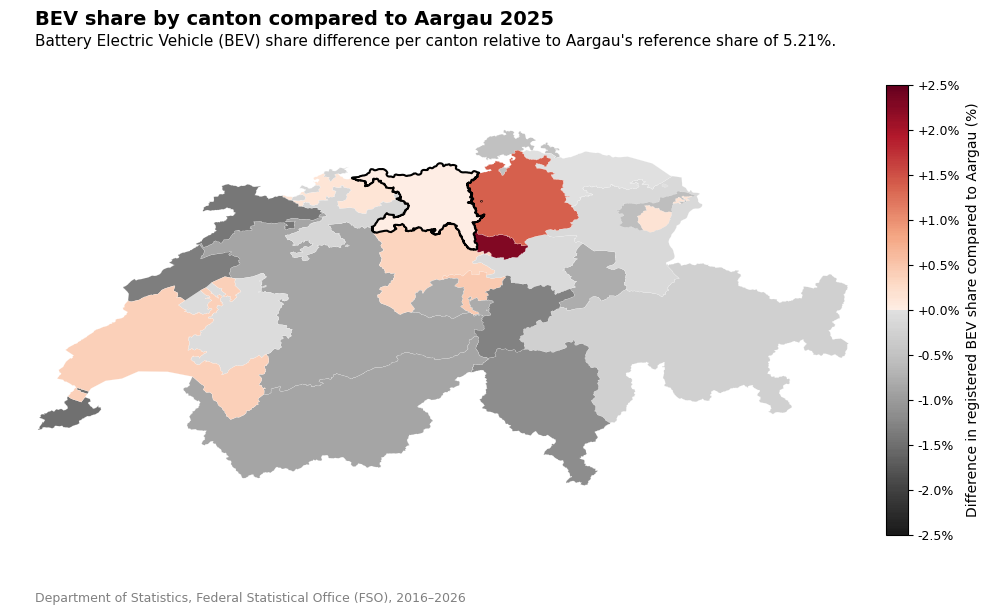

Saved: ..\docs\graphic_own\vis_c_map_0.png


In [68]:
map_df = bar_df.reset_index().copy()
map_df["bfs"] = map_df["Canton"].map(canton_bfs)
map_df["delta"] = map_df["bev_share"] - aargau_share

# Diverging colormap: grey=below Aargau, red=above Aargau
cmap_full = plt.cm.RdGy_r
left = cmap_full(np.linspace(0.0, 0.40, 128))
right = cmap_full(np.linspace(0.55, 1.0, 128))
cmap = LinearSegmentedColormap.from_list("RdGy_r_clipped", np.vstack([left, right]))

fixed_min, fixed_max = -2.5, 2.5
norm = mcolors.TwoSlopeNorm(vmin=fixed_min, vcenter=0, vmax=fixed_max)

# Fetch Swisstopo geometries once
canton_polygons = {}
for _, row in map_df.dropna(subset=["bfs"]).iterrows():
    bfs = int(row["bfs"])
    url = (
        "https://api3.geo.admin.ch/rest/services/api/MapServer/"
        f"ch.swisstopo.swissboundaries3d-kanton-flaeche.fill/{bfs}"
        "?geometryFormat=geojson&sr=4326"
    )
    response = urllib.request.urlopen(url, timeout=30)
    payload = json.loads(response.read().decode("utf-8"))
    canton_polygons[bfs] = payload["feature"]["geometry"]["coordinates"]

fig, ax = plt.subplots(figsize=figure_size)

all_patches, all_colors = [], []
ar_patches, ar_color = [], 0.0
ai_patches, ai_color = [], 0.0
aargau_patches = []

for _, row in map_df.dropna(subset=["bfs"]).iterrows():
    bfs = int(row["bfs"])
    is_aargau = row["Canton"] == "Aargau"
    is_ai = row["Canton"] == "Appenzell Innerrhoden"
    is_ar = row["Canton"] == "Appenzell Ausserrhoden"
    for polygon in canton_polygons[bfs]:
        p = Polygon(polygon[0], closed=True)
        if is_aargau:
            aargau_patches.append(p)
        elif is_ai:
            ai_patches.append(p)
            ai_color = row["delta"]
        elif is_ar:
            ar_patches.append(p)
            ar_color = row["delta"]
        else:
            all_patches.append(p)
            all_colors.append(row["delta"])

collection = PatchCollection(all_patches, cmap=cmap, norm=norm,
                             edgecolor="white", linewidth=0.1)
collection.set_array(pd.Series(all_colors))
ax.add_collection(collection)

ar_collection = PatchCollection(ar_patches, cmap=cmap, norm=norm,
                                edgecolor="white", linewidth=0.1)
ar_collection.set_array(pd.Series([ar_color] * len(ar_patches)))
ax.add_collection(ar_collection)

ai_collection = PatchCollection(ai_patches, cmap=cmap, norm=norm,
                                edgecolor="white", linewidth=0.1)
ai_collection.set_array(pd.Series([ai_color] * len(ai_patches)))
ax.add_collection(ai_collection)

aargau_collection = PatchCollection(aargau_patches, facecolor=cmap(norm(0)),
                                    edgecolor="black", linewidth=1.5)
ax.add_collection(aargau_collection)

ax.set_xlim(5.8, 10.6)
ax.set_ylim(45.7, 47.9)
ax.set_aspect("equal")
ax.set_axis_off()

sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])
cbar = plt.colorbar(sm, ax=ax, fraction=0.025, pad=0.02)
cbar.set_ticks(np.arange(-2.5, 3.0, 0.5))
cbar.ax.yaxis.set_major_formatter(FuncFormatter(lambda x, _: f"{x:+.1f}%"))
cbar.ax.tick_params(labelsize=9)
cbar.set_label("Difference in registered BEV share compared to Aargau (%)", fontsize=10)

fig.text(s=f"BEV share by canton compared to Aargau {latest_year}", **title_cfg)
fig.text(s=f"Battery Electric Vehicle (BEV) share difference per canton relative to Aargau's reference share of {aargau_share:.2f}%.",
         **subtitle_cfg)

fig.text(**data_source_cfg)

plt.tight_layout()
plt.subplots_adjust(**cfg["plot_space"])

map_path = output_dir / "vis_c_map_0.png"
plt.savefig(map_path, **saving_cfg)
plt.show()
print(f"Saved: {map_path}")

Ignoring fixed y limits to fulfill fixed data aspect with adjustable data limits.


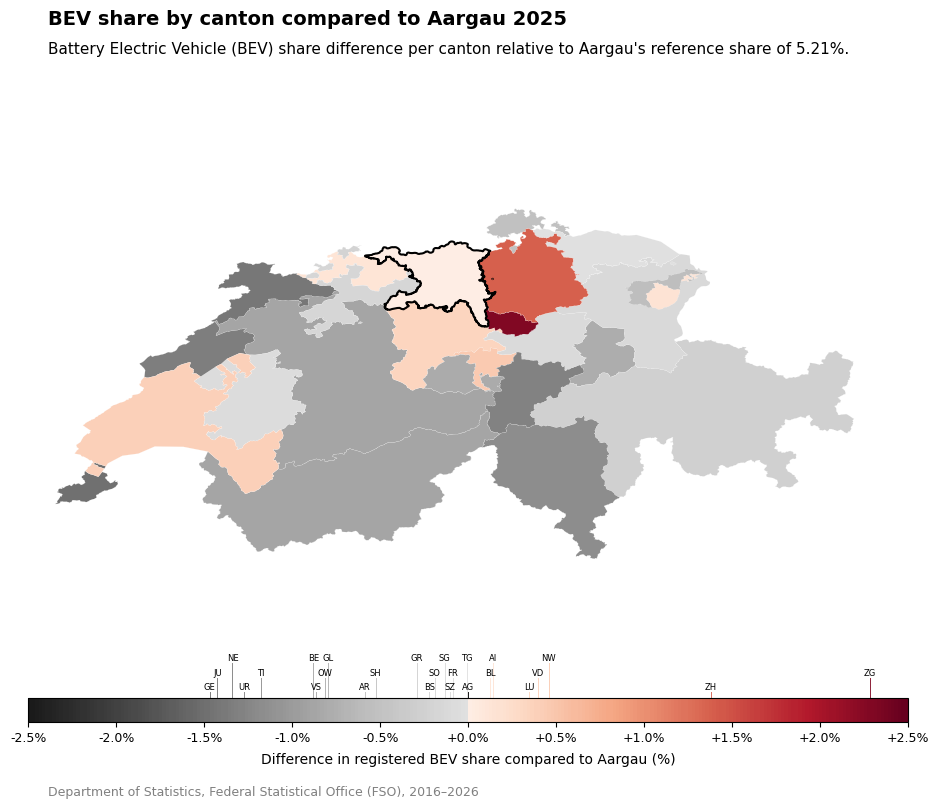

Saved: ..\docs\graphic_own\vis_c_map_1.png


In [69]:
map_df["short"] = map_df["Canton"].map(canton_short)

fig, (ax_map, ax_cbar) = plt.subplots(
    2, 1, figsize=(figure_size[0], figure_size[1] + 2),
    gridspec_kw={"height_ratios": [24, 1], "hspace": 0.08},
)

all_patches, all_colors = [], []
ar_patches, ar_color = [], 0.0
ai_patches, ai_color = [], 0.0
aargau_patches = []

for _, row in map_df.dropna(subset=["bfs"]).iterrows():
    bfs = int(row["bfs"])
    is_aargau = row["Canton"] == "Aargau"
    is_ai = row["Canton"] == "Appenzell Innerrhoden"
    is_ar = row["Canton"] == "Appenzell Ausserrhoden"
    for polygon in canton_polygons[bfs]:
        p = Polygon(polygon[0], closed=True)
        if is_aargau:
            aargau_patches.append(p)
        elif is_ai:
            ai_patches.append(p)
            ai_color = row["delta"]
        elif is_ar:
            ar_patches.append(p)
            ar_color = row["delta"]
        else:
            all_patches.append(p)
            all_colors.append(row["delta"])

collection = PatchCollection(all_patches, cmap=cmap, norm=norm,
                             edgecolor="white", linewidth=0.1)
collection.set_array(pd.Series(all_colors))
ax_map.add_collection(collection)

ar_collection = PatchCollection(ar_patches, cmap=cmap, norm=norm,
                                edgecolor="white", linewidth=0.1)
ar_collection.set_array(pd.Series([ar_color] * len(ar_patches)))
ax_map.add_collection(ar_collection)

ai_collection = PatchCollection(ai_patches, cmap=cmap, norm=norm,
                                edgecolor="white", linewidth=0.1)
ai_collection.set_array(pd.Series([ai_color] * len(ai_patches)))
ax_map.add_collection(ai_collection)

aargau_collection = PatchCollection(aargau_patches, facecolor=cmap(norm(0)),
                                    edgecolor="black", linewidth=1.5)
ax_map.add_collection(aargau_collection)


ax_map.set_xlim(5.8, 10.8)
ax_map.set_ylim(45.7, 47.9)
ax_map.set_aspect("equal", adjustable="datalim")
ax_map.axis("off")

sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])
cbar = fig.colorbar(sm, cax=ax_cbar, orientation="horizontal")
cbar.set_ticks(np.arange(-2.5, 3.0, 0.5))
cbar.set_label("Difference in registered BEV share compared to Aargau (%)", fontsize=10, labelpad=6)
cbar.ax.xaxis.set_major_formatter(FuncFormatter(lambda x, _: f"{x:+.1f}%"))
cbar.ax.xaxis.set_ticks_position("bottom")
cbar.ax.xaxis.set_label_position("bottom")
cbar.ax.set_xlim(fixed_min, fixed_max)
cbar.ax.tick_params(labelsize=9)

# Tick labels for each canton, leadered to its delta value
for i, (_, row) in enumerate(map_df.dropna(subset=["bfs"]).sort_values("delta").iterrows()):
    d = float(np.clip(row["delta"], fixed_min, fixed_max))
    short = row["short"]
    is_ag = row["Canton"] == "Aargau"
    offset = 1.25 + (i % 3) * 0.6
    color = "black" if is_ag else cmap(norm(row["delta"]))

    cbar.ax.plot([d, d], [1.0, offset], color=color, linewidth=0.7, alpha=0.9,
                 transform=cbar.ax.get_xaxis_transform(), clip_on=False)
    cbar.ax.text(d, offset, short, va="bottom", ha="center", fontsize=6,
                 color="black", rotation=0, alpha=1,
                 transform=cbar.ax.get_xaxis_transform(), clip_on=False)

fig.text(s=f"BEV share by canton compared to Aargau {latest_year}", **title_cfg)
fig.text(s=f"Battery Electric Vehicle (BEV) share difference per canton relative to Aargau's reference share of {aargau_share:.2f}%.",
         **subtitle_cfg)

fig.text(**data_source_cfg)

plt.subplots_adjust(left=0.02,**cfg["plot_space"])

map_path = output_dir / "vis_c_map_1.png"
plt.savefig(map_path, **saving_cfg)
plt.show()
print(f"Saved: {map_path}")

## Bar chart

C:\Users\juan-\AppData\Local\Temp\ipykernel_39256\2297716288.py:22: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(plot_df["label"], rotation=0, fontsize=9)


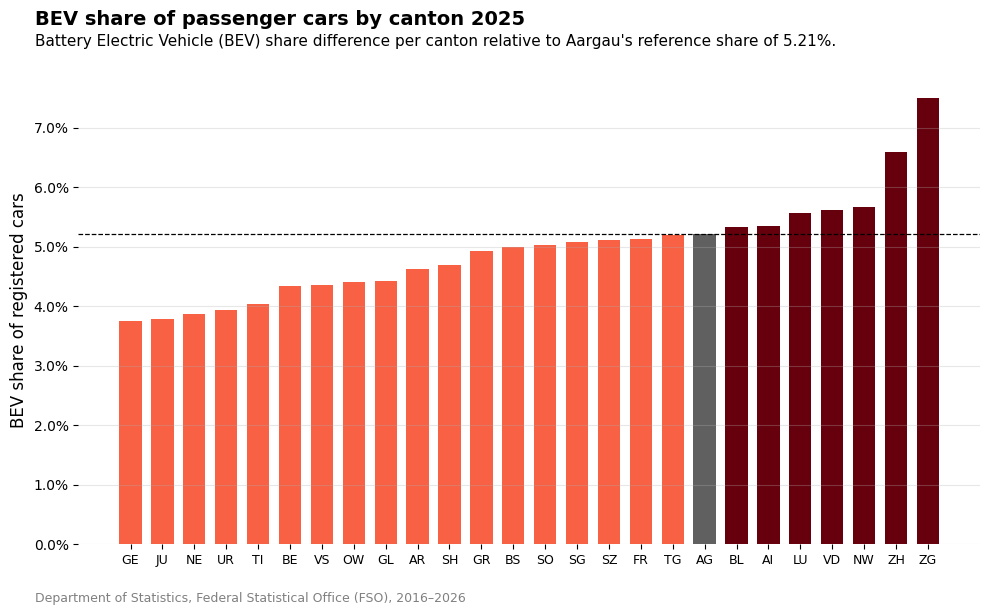

Saved: ..\docs\graphic_own\vis_c_bar_0.png


In [70]:
plot_df = bar_df[["bev_share"]].copy().sort_values("bev_share", ascending=True)
plot_df["label"] = plot_df.index.map(lambda x: canton_short.get(x, x))
plot_df["is_aargau"] = plot_df.index == "Aargau"

bar_colors = [
    COL_AG if (row["is_aargau"] or np.isclose(row["bev_share"], aargau_share))
    else (COL_POS if row["bev_share"] > aargau_share else COL_NEG)
    for _, row in plot_df.iterrows()
]

fig, ax = plt.subplots(figsize=figure_size)
ax.bar(x=plot_df["label"], height=plot_df["bev_share"], color=bar_colors, width=0.7)

ax.axhline(y=aargau_share, color="black", linewidth=0.9, linestyle="--", zorder=2)

for spine in ax.spines.values():
    spine.set_visible(False)

ax.grid(alpha=0.3, axis="y")
ax.yaxis.set_major_formatter(PercentFormatter())
ax.set_ylabel("BEV share of registered cars", fontsize=12)
ax.set_xticklabels(plot_df["label"], rotation=0, fontsize=9)

fig.text(s=f"BEV share of passenger cars by canton {latest_year}", **title_cfg)
fig.text(s=f"Battery Electric Vehicle (BEV) share difference per canton relative to Aargau's reference share of {aargau_share:.2f}%.",
         **subtitle_cfg)

fig.text(**data_source_cfg)

plt.tight_layout()
plt.subplots_adjust(**cfg["plot_space"])

bar_path = output_dir / "vis_c_bar_0.png"
plt.savefig(bar_path, **saving_cfg)
plt.show()
print(f"Saved: {bar_path}")

C:\Users\juan-\AppData\Local\Temp\ipykernel_39256\1759098103.py:32: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(plot_df["label"], rotation=0, fontsize=9)


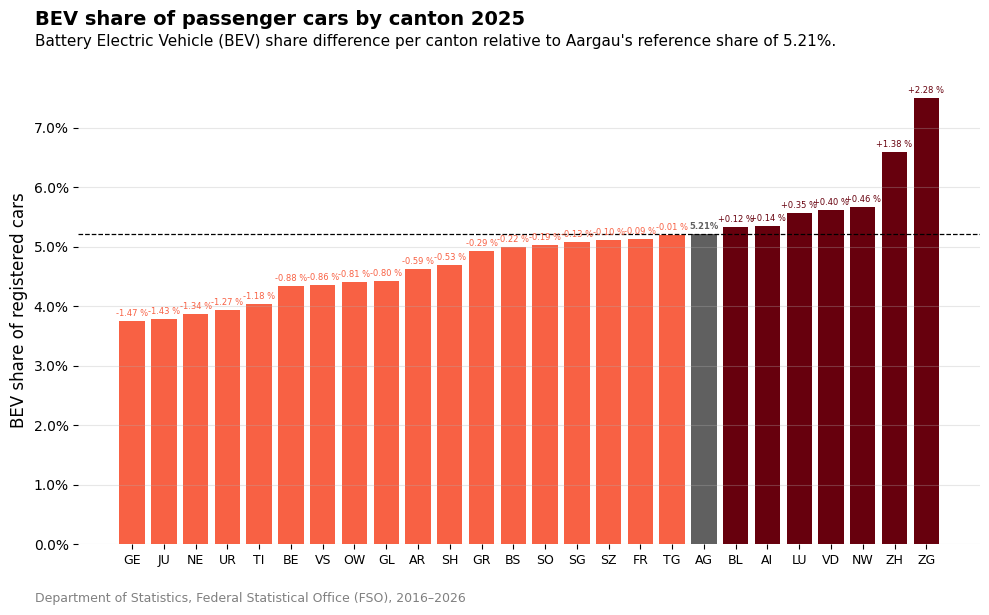

Saved: ..\docs\graphic_own\vis_c_bar_bev_1.png


In [71]:
bar_colors = [
    COL_AG if (row["is_aargau"] or np.isclose(row["bev_share"], aargau_share))
    else (COL_POS if row["bev_share"] > aargau_share else COL_NEG)
    for _, row in plot_df.iterrows()
]

fig, ax = plt.subplots(figsize=figure_size)
bars = ax.bar(x=plot_df["label"], height=plot_df["bev_share"], color=bar_colors, width=0.8)

# Per-bar labels: Aargau shows absolute share, others show delta vs. Aargau
for bar, (_, row) in zip(bars, plot_df.iterrows()):
    delta = row["bev_share"] - aargau_share
    if row["is_aargau"]:
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.05,
                f"{row['bev_share']:.2f}%",
                ha="center", va="bottom", fontsize=6, fontweight="bold",
                color=bar.get_facecolor())
    else:
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.05,
                f"{delta:+.2f} %",
                ha="center", va="bottom", fontsize=6,
                color=bar.get_facecolor())

ax.axhline(y=aargau_share, color="black", linewidth=0.9, linestyle="--", zorder=2)

for spine in ax.spines.values():
    spine.set_visible(False)

ax.grid(alpha=0.3, axis="y")
ax.yaxis.set_major_formatter(PercentFormatter())
ax.set_ylabel("BEV share of registered cars", fontsize=12)
ax.set_xticklabels(plot_df["label"], rotation=0, fontsize=9)

fig.text(s=f"BEV share of passenger cars by canton {latest_year}", **title_cfg)
fig.text(s=f"Battery Electric Vehicle (BEV) share difference per canton relative to Aargau's reference share of {aargau_share:.2f}%.",
         **subtitle_cfg)

fig.text(**data_source_cfg)

plt.tight_layout()
plt.subplots_adjust(**cfg["plot_space"])

bar_path = output_dir / "vis_c_bar_bev_1.png"
plt.savefig(bar_path, **saving_cfg)
plt.show()
print(f"Saved: {bar_path}")

C:\Users\juan-\AppData\Local\Temp\ipykernel_39256\333012016.py:31: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(plot_df["label"], rotation=0, fontsize=9)


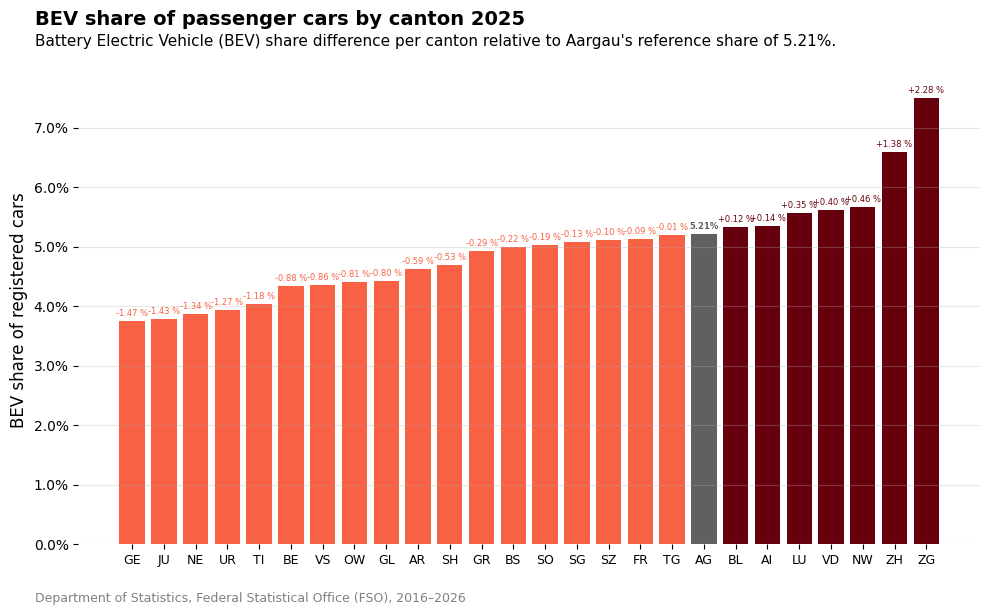

Saved: ..\docs\graphic_own\vis_c_bar_bev_2.png


In [72]:
bar_colors = [
    COL_AG if (row["is_aargau"] or np.isclose(row["bev_share"], aargau_share))
    else (COL_POS if row["bev_share"] > aargau_share else COL_NEG)
    for _, row in plot_df.iterrows()
]

fig, ax = plt.subplots(figsize=figure_size)
bars = ax.bar(x=plot_df["label"], height=plot_df["bev_share"], color=bar_colors, width=0.8)

# Per-bar labels: Aargau shows absolute share, others show delta vs. Aargau
for bar, (_, row) in zip(bars, plot_df.iterrows()):
    delta = row["bev_share"] - aargau_share
    if row["is_aargau"]:
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.05,
                f"{row['bev_share']:.2f}%",
                ha="center", va="bottom", fontsize=6, fontweight="bold",
                color=bar.get_facecolor())
    else:
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.05,
                f"{delta:+.2f} %",
                ha="center", va="bottom", fontsize=6,
                color=bar.get_facecolor())


for spine in ax.spines.values():
    spine.set_visible(False)

ax.grid(alpha=0.3, axis="y")
ax.yaxis.set_major_formatter(PercentFormatter())
ax.set_ylabel("BEV share of registered cars", fontsize=12)
ax.set_xticklabels(plot_df["label"], rotation=0, fontsize=9)

fig.text(s=f"BEV share of passenger cars by canton {latest_year}", **title_cfg)
fig.text(s=f"Battery Electric Vehicle (BEV) share difference per canton relative to Aargau's reference share of {aargau_share:.2f}%.",
         **subtitle_cfg)

fig.text(**data_source_cfg)

plt.tight_layout()
plt.subplots_adjust(**cfg["plot_space"])

bar_path = output_dir / "vis_c_bar_bev_2.png"
plt.savefig(bar_path, **saving_cfg)
plt.show()
print(f"Saved: {bar_path}")

##  Lollipop chart 

Anchored on Aargau as the zero reference. Cantons with a higher BEV share extend to the right, lower-share cantons extend to the left. Colour encodes direction (above/below) and Aargau itself is marked in neutral grey.

In [73]:
div_df = plot_df.copy()
div_df["delta"] = div_df["bev_share"] - aargau_share
div_df = div_df.sort_values("delta", ascending=True).reset_index(drop=False)

y_pos = range(len(div_df))

div_df["color"] = np.select(
    [div_df["is_aargau"] | np.isclose(div_df["delta"], 0), div_df["delta"] > 0],
    [COL_AG, COL_POS],
    default=COL_NEG,
)


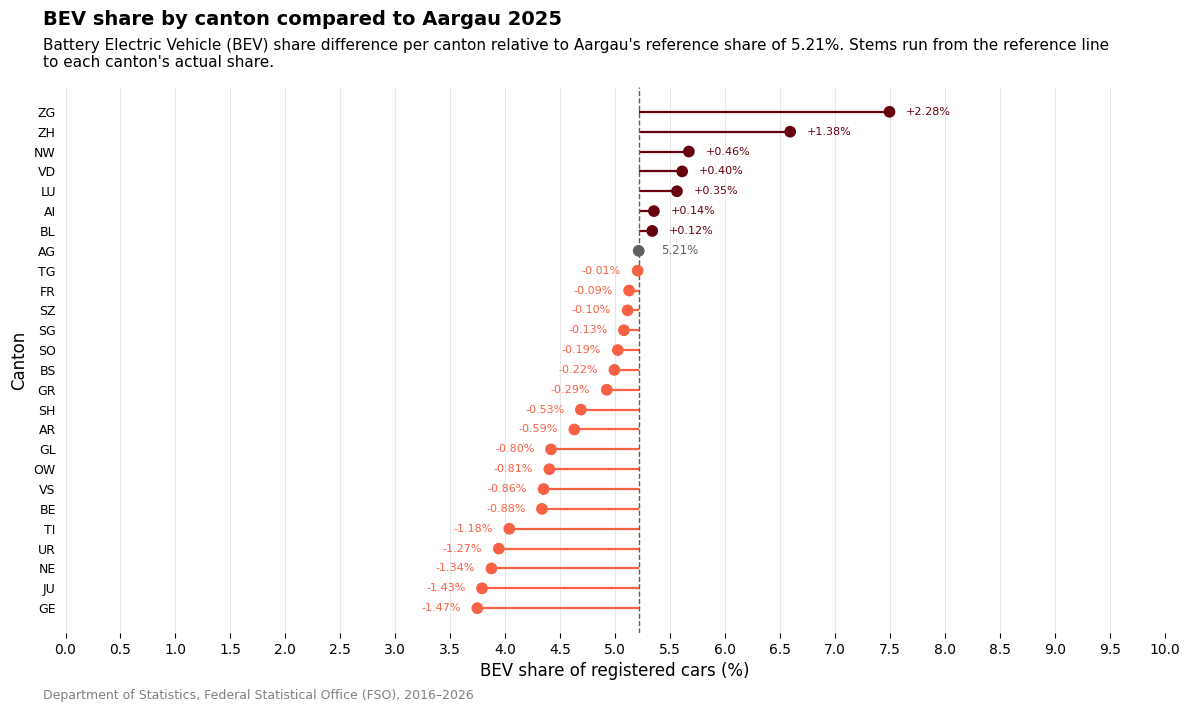

Saved: ..\docs\graphic_own\vis_c_lollipop_bev_delta_0.png


In [74]:
fig, ax = plt.subplots(figsize=(figure_size[0] + 2, figure_size[1] + 1))

ax.hlines(y=y_pos, xmin=aargau_share, xmax=div_df["bev_share"],
          colors=div_df["color"], linewidth=1.6)
ax.scatter(x=div_df["bev_share"], y=y_pos, color=div_df["color"], zorder=3, s=55)

ag_idx = div_df["is_aargau"].idxmax()
ax.scatter(x=[aargau_share], y=[ag_idx], color=COL_AG, linewidths=0.8)

ax.set_yticks(list(y_pos))
ax.set_yticklabels(div_df["label"], fontsize=9)
ax.axvline(x=aargau_share, color=COL_AG, linewidth=1, linestyle="--", zorder=2)

ax.annotate(f"{aargau_share:.2f}%", xy=(aargau_share, ag_idx),
            xytext=(aargau_share + 0.2, ag_idx), fontsize=8.5, color=COL_AG, va="center")

LABEL_OFFSET = 0.25
DELTA_OFFSET = 0.15
for _, row in div_df.iterrows():
    y = row.name
    is_right = row["bev_share"] >= aargau_share

    if row["is_aargau"]:
        pass
    else:
        ax.annotate(f"{row['delta']:+.2f}%",
                    xy=(row["bev_share"], y),
                    xytext=(row["bev_share"] + DELTA_OFFSET if is_right else row["bev_share"] - DELTA_OFFSET, y),
                    fontsize=8, color=row["color"],
                    ha="left" if is_right else "right", va="center")

ax.set_xlim(0, 10)
ax.set_xticks(np.arange(0, 10.5, 0.5))
ax.xaxis.set_major_formatter(FuncFormatter(lambda x, _: f"{x:.1f}"))
ax.set_xlabel("BEV share of registered cars (%)", fontsize=12)
ax.set_ylabel("Canton", fontsize=12)

for spine in ax.spines.values():
    spine.set_visible(False)

ax.grid(alpha=0.3, axis="x")
ax.tick_params(axis="y", left=False)

fig.text(s=f"BEV share by canton compared to Aargau {latest_year}", **title_cfg)
fig.text(s=f"Battery Electric Vehicle (BEV) share difference per canton relative to Aargau's reference share of {aargau_share:.2f}%. Stems run from the reference line\nto each canton's actual share.",
         **subtitle_cfg)

fig.text(**data_source_cfg)

plt.tight_layout()
plt.subplots_adjust(**cfg["plot_space"])

out_path = output_dir / "vis_c_lollipop_bev_delta_0.png"
plt.savefig(out_path, **saving_cfg)
plt.show()
print(f"Saved: {out_path}")


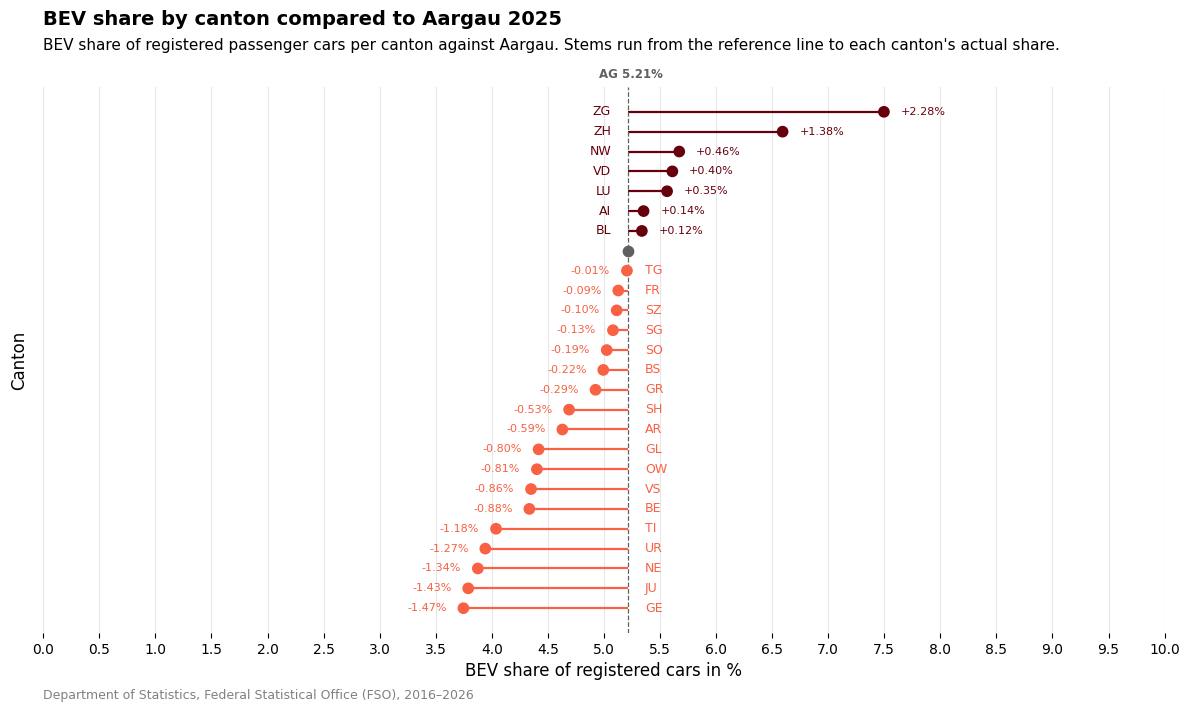

Saved: ..\docs\graphic_own\vis_c_lollipop_bev_delta_1.png


In [75]:
fig, ax = plt.subplots(figsize=(figure_size[0] + 2, figure_size[1] + 1))

non_ag = div_df[~div_df["is_aargau"]]

ax.hlines(y=non_ag.index, xmin=aargau_share, xmax=non_ag["bev_share"],
          colors=non_ag["color"], linewidth=1.6)

ax.scatter(x=non_ag["bev_share"], y=non_ag.index, color=non_ag["color"], zorder=3, s=55)

ag_idx = div_df["is_aargau"].idxmax()
ax.scatter(x=[aargau_share], y=[ag_idx], color=COL_AG, zorder=3, s=55)

ax.set_yticks(list(y_pos))
ax.set_yticklabels([""] * len(div_df))
ax.axvline(x=aargau_share, color=COL_AG, linewidth=0.9, linestyle="--", zorder=2)

ax.annotate(f"AG {aargau_share:.2f}%", xy=(aargau_share, 1), xycoords=("data", "axes fraction"),
            xytext=(2, 4), textcoords="offset points",
            fontsize=8.5, fontweight="bold", color=COL_AG, va="bottom", ha="center")

LABEL_OFFSET = 0.25
DELTA_OFFSET = 0.15
for _, row in div_df.iterrows():
    y = row.name
    is_right = row["bev_share"] >= aargau_share
    if row["is_aargau"]:
        pass
    else:
        ax.annotate(f"{row['delta']:+.2f}%",
                    xy=(row["bev_share"], y),
                    xytext=(row["bev_share"] + DELTA_OFFSET if is_right else row["bev_share"] - DELTA_OFFSET, y),
                    fontsize=8, color=row["color"],
                    ha="left" if is_right else "right", va="center")
        ax.annotate(row["label"],
                    xy=(aargau_share, y),
                    xytext=(aargau_share - DELTA_OFFSET if is_right else aargau_share + DELTA_OFFSET, y),
                    fontsize=9, color=row["color"],
                    ha="right" if is_right else "left", va="center")

ax.set_xlim(0, 10)
ax.set_xticks(np.arange(0, 10.5, 0.5))
ax.xaxis.set_major_formatter(FuncFormatter(lambda x, _: f"{x:.1f}"))
ax.set_xlabel("BEV share of registered cars in %", fontsize=12)
ax.set_ylabel("Canton", fontsize=12)

for spine in ax.spines.values():
    spine.set_visible(False)

ax.grid(alpha=0.3, axis="x")
ax.tick_params(axis="y", left=False)

fig.text(s=f"BEV share by canton compared to Aargau {latest_year}", **title_cfg)
fig.text(s=f"BEV share of registered passenger cars per canton against Aargau. Stems run from the reference line to each canton's actual share.",
         **subtitle_cfg)

fig.text(**data_source_cfg)

plt.tight_layout()
plt.subplots_adjust(**cfg["plot_space"])

out_path = output_dir / "vis_c_lollipop_bev_delta_1.png"
plt.savefig(out_path, **saving_cfg)
plt.show()
print(f"Saved: {out_path}")
